In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets


(-0.5, 799.5, 499.5, -0.5)

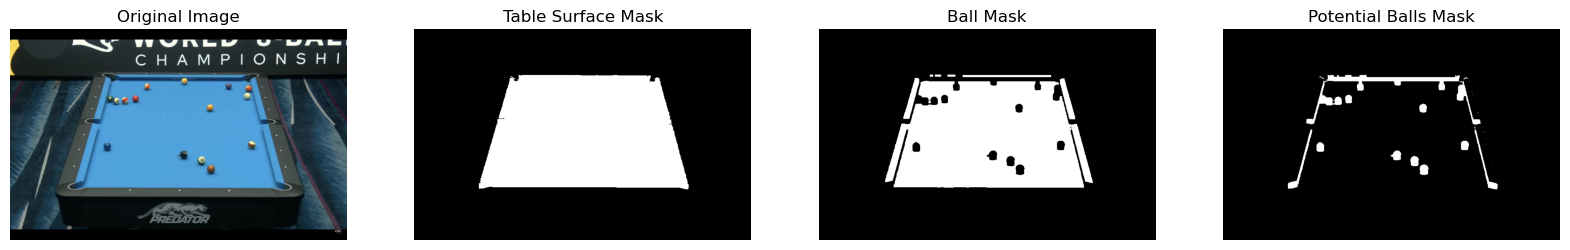

In [48]:
IMAGE_PATH= "./data/development_set/3f_png.rf.81c7e132365ef95bb19380ca389025f6.jpg"
img = cv2.imread(IMAGE_PATH)

f, axarr = plt.subplots(1, 4, figsize=(20, 10))

#RESIZING
height, width = img.shape[:2]
img = cv2.resize(img, (800, int(800 * height / width)))
axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Original Image")
axarr[0].axis("off")

#TABLE MASK
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_blue = np.array([100, 150, 0])
upper_blue = np.array([140, 255, 255])

# create a mask of the blue table
table_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# clean the mask using morphological operations
kernel = np.ones((5, 5), np.uint8)
table_mask_denoised = cv2.morphologyEx(table_mask, cv2.MORPH_CLOSE, kernel)
table_mask_denoised = cv2.morphologyEx(table_mask, cv2.MORPH_OPEN, kernel)

# finf the largest blue contour (should be the table surface)
contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

# clean mask where only the table will be
surface_mask = np.zeros_like(table_mask)
cv2.drawContours(surface_mask, [largest_contour], -1, 255, -1)

axarr[1].imshow(surface_mask, cmap="gray")
axarr[1].set_title("Table Surface Mask")
axarr[1].axis("off")

#BALLS MASK
lower = np.array([95, 140, 180])
upper = np.array([115, 210, 255])

ball_mask = cv2.inRange(hsv, lower, upper)
kernel = np.ones((5, 5), np.uint8)
ball_mask_denoised = cv2.morphologyEx(ball_mask, cv2.MORPH_CLOSE, kernel)
ball_mask_denoised = cv2.morphologyEx(ball_mask, cv2.MORPH_OPEN, kernel)

axarr[2].imshow(ball_mask_denoised, cmap="gray")
axarr[2].set_title("Ball Mask")
axarr[2].axis("off")

inverted_ball_mask = cv2.bitwise_not(ball_mask_denoised)

potential_balls_mask = cv2.bitwise_and(inverted_ball_mask, inverted_ball_mask, mask=surface_mask)

axarr[3].imshow(potential_balls_mask, cmap="gray")
axarr[3].set_title("Potential Balls Mask")
axarr[3].axis("off")


Median radius: 11.0
Detected circles: 14


(-0.5, 799.5, 499.5, -0.5)

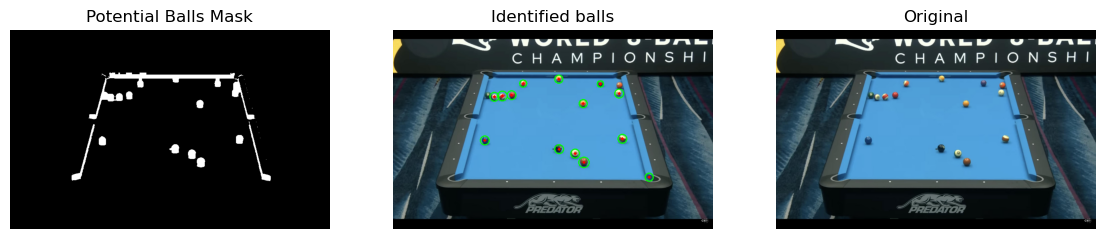

In [129]:
circles = cv2.HoughCircles(potential_balls_mask, cv2.HOUGH_GRADIENT_ALT, dp=1, minDist=10, param1=300, param2=0.1)

img_cpy = img.copy()

if circles is not None:
    circles = np.int16(np.around(circles))

    median_radius = np.median(circles[0, :, 2])
    print(f"Median radius: {median_radius}")

    print(f"Detected circles: {len(circles[0, :])}")

    for i in circles[0, :]:
        if((median_radius-10)<i[2]<(median_radius+10) or True):
            # draw the outer circle
            cv2.circle(img_cpy, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # draw the center of the circle
            cv2.circle(img_cpy, (i[0], i[1]), 2, (0, 0, 255), 3)
else:
    print("Detected circles: 0")
    print("Filtered circles: 0")

f, axarr = plt.subplots(1, 3, figsize=(14, 4))

axarr[0].imshow(cv2.cvtColor(potential_balls_mask, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Potential Balls Mask")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img_cpy, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Identified balls")
axarr[1].axis("off")

axarr[2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[2].set_title("Original")
axarr[2].axis("off")

Median radius: 10.53105640411377
Circle found at (273, 170) with radius 11
Circle found at (414, 123) with radius 11
Circle found at (326, 135) with radius 10
Circle found at (297, 165) with radius 11
Circle found at (519, 135) with radius 10
Circle found at (477, 332) with radius 11
Circle found at (414, 297) with radius 11
Circle found at (454, 310) with radius 11
Circle found at (573, 274) with radius 10
Circle found at (231, 278) with radius 10
Circle found at (252, 171) with radius 10
Circle found at (474, 186) with radius 9
Circle found at (237, 166) with radius 9
Circle found at (567, 140) with radius 9
Circle found at (562, 159) with radius 9


(-0.5, 799.5, 499.5, -0.5)

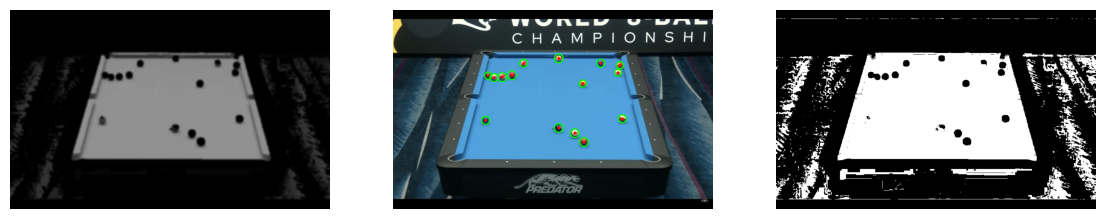

In [ ]:
# Convert to grayscale — HoughCircles needs single channel
img_test = img.copy()
gray = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
gray = cv2.bitwise_and(gray, gray, mask=table_mask)
#gray = cv2.bitwise_and(gray, gray, mask=surface_mask) #the voting is perfect without the surface mask, without false positives in the table

# Blur first — reduces noise, improves circle detection significantly
blurred = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT_ALT,
    dp=1.5,
    minDist=10,
    param1=300,
    param2=0.1
)

median_test_radius = np.median(circles[0, :, 2])
print(f"Median radius: {median_test_radius}")
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    for x, y, r in circles:
      if(surface_mask[y, x] > 0): #this is a work around the fact that the voting is perfect without the surface mask, without false positives in the table, but it still detects circles outside the table surface, so we need to check if the center of the circle is inside the surface mask
        if((median_test_radius-5)<r<(median_test_radius+1)):
              print(f"Circle found at ({x}, {y}) with radius {r}")
              # draw the outer circle
              cv2.circle(img_test, (x, y), r, (0, 255, 0), 2)
              # draw the center of the circle
              cv2.circle(img_test, (x, y), 2, (0, 0, 255), 3)

f, axarr = plt.subplots(1, 3, figsize=(14, 4))
axarr[0].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
axarr[1].axis("off")

axarr[2].imshow(table_mask, cmap="gray")
axarr[2].axis("off")